# BCI Competition III — Dataset IVa: Motor Imagery Classification

## Dataset description

**Source:** Fraunhofer FIRST / Charité Berlin (Blankertz et al., 2006)

Five healthy subjects (*aa, al, av, aw, ay*) performed **motor imagery** of two limbs:
- **Class 1 — right hand** imagery
- **Class 2 — right foot** imagery

EEG was recorded from **118 channels** at **100 Hz** using a BrainAmp amplifier.

## Task & experimental design

Each trial (total 280 per subject) began with a fixation cross for 2 s followed by a visual cue (arrow pointing right or down) displayed for 3.5 s. Subjects were asked to imagine the corresponding limb movement throughout the cue period. Trials were separated by a random inter-trial interval.

```
  t = 0 s         t = 0.5 s           t = 2.5 s     t = 3.5 s
  |  fixation  |  ← classify here →  |    rest    |
  cue onset         epoch window
```

The standard 2 s analysis window starts at 0.5 s post-cue to avoid the early visual evoked response and captures the **mu (8–12 Hz)** and **beta (18–26 Hz) event-related desynchronisation (ERD)** that accompanies motor imagery.

## Competition challenge

Training and test sets were split **unequally across subjects** — from 168 labeled trials (aa) down to just 28 (ay). The challenge was therefore as much about generalising with very little data as about classification accuracy. Here we use only labeled trials and evaluate with stratified k-fold cross-validation within each subject.

## Reference

> Blankertz, B., Müller, K.-R., et al. (2006). *The BCI Competition III: Validating alternative approaches to actual BCI problems.* IEEE Transactions on Neural Systems and Rehabilitation Engineering, 14(2), 153–159.

In [5]:
import numpy as np
import scipy.io as sio
from scipy.signal import butter, filtfilt, welch
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

from sklearn.pipeline import make_pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

from mne.decoding import CSP
from pyriemann.estimation import Covariances
from pyriemann.classification import MDM, FgMDM
from pyriemann.tangentspace import TangentSpace

DATA_DIR = Path('../data/BCI_Comp_III_IVa/100Hz')
SUBJECTS  = ['aa', 'al', 'av', 'aw', 'ay']
FS        = 100.0   # Hz
SEED      = 42

## Load & preprocess

Steps per subject:
1. Load continuous EEG (int16 → µV scale)
2. Bandpass filter 8–30 Hz (mu + beta band)
3. Extract epochs: **0.5 – 2.5 s post cue** (200 samples at 100 Hz)
4. Keep only labeled trials (y ≠ NaN); recode labels to {0, 1}

In [ ]:
T_START  = 0.5   # s post cue — skip early VEP
T_END    = 2.5   # s post cue
N_START  = int(T_START * FS)
N_END    = int(T_END   * FS)
N_EPOCH  = N_END - N_START   # 200 samples = 2 s

# 15 sensorimotor channels — avoids slow 118×118 covariance matrices
SMR_CH = ['FC3','FC1','FCz','FC2','FC4',
          'C3', 'C1', 'Cz', 'C2', 'C4',
          'CP3','CP1','CPz','CP2','CP4']

def bandpass(data, lo=8., hi=30., fs=FS, order=5):
    from scipy.signal import butter, filtfilt
    b, a = butter(order, [lo/(fs/2), hi/(fs/2)], btype='band')
    return filtfilt(b, a, data, axis=0)

subjects_data = {}
for subj in SUBJECTS:
    mat  = sio.loadmat(DATA_DIR / f'data_set_IVa_{subj}.mat')
    cnt  = mat['cnt'].astype(np.float32) * 0.1
    mrk  = mat['mrk'][0, 0]
    nfo  = mat['nfo'][0, 0]
    pos  = mrk['pos'].flatten().astype(int)
    y    = mrk['y'].flatten()
    clab = [str(nfo['clab'][0, i][0]) for i in range(nfo['clab'].shape[1])]

    ch_idx   = [clab.index(c) for c in SMR_CH if c in clab]
    ch_names = [clab[i] for i in ch_idx]

    cnt_filt = bandpass(cnt[:, ch_idx])

    epochs, labels = [], []
    for t_idx, t_pos in enumerate(pos):
        if np.isnan(y[t_idx]):
            continue
        start = t_pos + N_START
        end   = t_pos + N_END
        if end > len(cnt_filt):
            continue
        epochs.append(cnt_filt[start:end])
        labels.append(int(y[t_idx]) - 1)   # 0=right, 1=foot

    X     = np.stack(epochs)
    y_bin = np.array(labels)
    subjects_data[subj] = dict(X=X, y=y_bin, clab=ch_names)
    print(f'  {subj}: {X.shape[0]} trials  shape {X.shape}  '
          f'({(y_bin==0).sum()} right, {(y_bin==1).sum()} foot)')


## ERD/ERS visualisation

Motor imagery suppresses oscillatory activity in contralateral sensorimotor cortex (**event-related desynchronisation, ERD**) in the mu (8–12 Hz) and beta (18–26 Hz) bands. Right-hand imagery should produce stronger ERD over left hemisphere (C3), foot imagery over central vertex (Cz).

Channels found: {'C3': 51, 'Cz': 53, 'C4': 55}


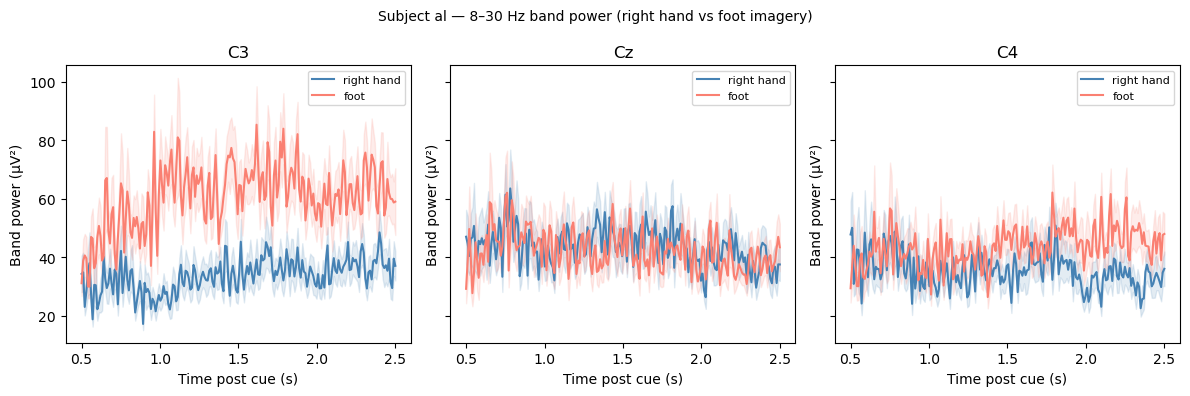

In [7]:
%matplotlib inline

PLOT_SUBJ = 'al'   # most data
d    = subjects_data[PLOT_SUBJ]
clab = d['clab']

# Find C3, Cz, C4 (or nearest)
def find_ch(clab, name):
    try: return clab.index(name)
    except ValueError: return None

ch_map = {n: find_ch(clab, n) for n in ['C3', 'Cz', 'C4']}
ch_map = {k: v for k, v in ch_map.items() if v is not None}
print('Channels found:', ch_map)

t_ax = np.linspace(T_START, T_END, N_EPOCH)

fig, axes = plt.subplots(1, len(ch_map), figsize=(4 * len(ch_map), 4), sharey=True)
if len(ch_map) == 1: axes = [axes]

for ax, (ch_name, ch_idx) in zip(axes, ch_map.items()):
    for cls, color, label in [(0, 'steelblue', 'right hand'), (1, 'salmon', 'foot')]:
        mask = d['y'] == cls
        ep   = d['X'][mask, :, ch_idx]    # (n_trials, N_EPOCH)
        # power proxy: squared amplitude
        pwr  = (ep ** 2)
        mu   = pwr.mean(0)
        se   = pwr.std(0) / np.sqrt(mask.sum())
        ax.plot(t_ax, mu, color=color, label=label)
        ax.fill_between(t_ax, mu - se, mu + se, alpha=0.15, color=color)
    ax.set_title(ch_name)
    ax.set_xlabel('Time post cue (s)')
    ax.set_ylabel('Band power (µV²)')
    ax.legend(fontsize=8)

fig.suptitle(f'Subject {PLOT_SUBJ} — 8–30 Hz band power (right hand vs foot imagery)', fontsize=10)
plt.tight_layout()
plt.show()

## Common Spatial Patterns (CSP)

CSP finds spatial filters **W** that maximise the ratio of variances between two classes. For motor imagery the resulting patterns correspond to the spatial distribution of ERD/ERS activity. The log-variance of CSP-filtered signals is used as features.

Standard pipeline:
```
X (n_trials, n_ch, n_time) → CSP → log-variance (n_trials, n_components) → LDA
```

In [ ]:
%matplotlib inline
import warnings

N_CSP   = 6
N_FOLDS = 3

MODELS = {
    'CSP + LDA':          make_pipeline(
                              CSP(n_components=N_CSP, reg='ledoit_wolf', log=True),
                              LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')),
    'CSP + LR':           make_pipeline(
                              CSP(n_components=N_CSP, reg='ledoit_wolf', log=True),
                              LogisticRegression(max_iter=1000)),
    'CSP + SVM-RBF':      make_pipeline(
                              CSP(n_components=N_CSP, reg='ledoit_wolf', log=True),
                              StandardScaler(),
                              SVC(kernel='rbf', probability=True)),
    'MDM':                make_pipeline(
                              Covariances(estimator='lwf'),
                              MDM(metric='riemann')),
    'FgMDM':              make_pipeline(
                              Covariances(estimator='lwf'),
                              FgMDM(metric='riemann', tsupdate=False)),
    'TangentSpace + LDA': make_pipeline(
                              Covariances(estimator='lwf'),
                              TangentSpace(metric='riemann'),
                              LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')),
}

cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

rows = []
for subj in SUBJECTS:
    d    = subjects_data[subj]
    X_3d = d['X'].transpose(0, 2, 1).astype(np.float64)  # (n_trials, n_ch, n_time)
    y    = d['y']
    for model_name, pipe in MODELS.items():
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            scores = cross_val_score(pipe, X_3d, y, cv=cv,
                                     scoring='roc_auc', n_jobs=-1)
        rows.append(dict(subject=subj, model=model_name,
                         auc=scores.mean(), auc_std=scores.std(),
                         n_trials=len(y)))
    print(f'  {subj} done')

df = pd.DataFrame(rows)
pivot = df.pivot(index='subject', columns='model', values='auc').round(3)
pivot.loc['mean'] = pivot.mean()
print()
print(pivot.to_string())


## Results

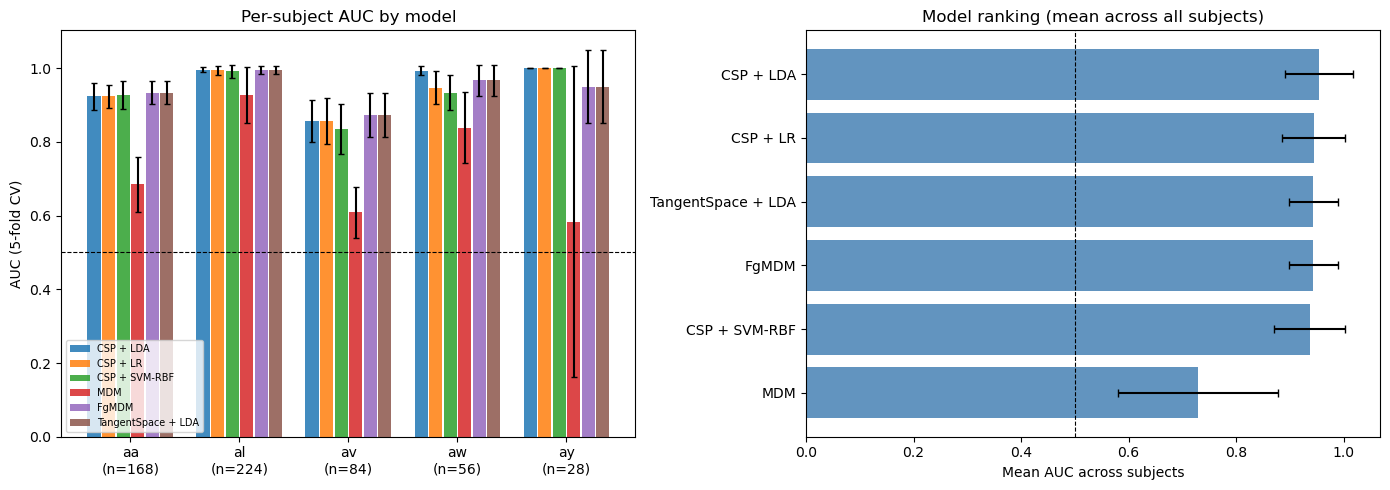

In [9]:
%matplotlib inline

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── left: per-subject per-model bar chart ────────────────────────────────
ax = axes[0]
model_names = df['model'].unique()
x = np.arange(len(SUBJECTS))
width = 0.8 / len(model_names)
for i, name in enumerate(model_names):
    sub = df[df['model'] == name].set_index('subject').reindex(SUBJECTS)
    ax.bar(x + i * width, sub['auc'], width=width * 0.9,
           yerr=sub['auc_std'], capsize=2, label=name, alpha=0.85)
ax.axhline(0.5, color='k', lw=0.8, ls='--')
ax.set_xticks(x + width * (len(model_names) - 1) / 2)
ax.set_xticklabels([f'{s}\n(n={subjects_data[s]["y"].shape[0]})' for s in SUBJECTS])
ax.set_ylabel('AUC (5-fold CV)')
ax.set_title('Per-subject AUC by model')
ax.legend(fontsize=7)

# ── right: mean AUC per model sorted ────────────────────────────────────
ax = axes[1]
mean_per_model = df.groupby('model')['auc'].mean().sort_values()
std_per_model  = df.groupby('model')['auc'].std().reindex(mean_per_model.index)
colors = ['steelblue' if v >= 0.7 else 'gray' if v >= 0.55 else 'salmon'
          for v in mean_per_model.values]
ax.barh(mean_per_model.index, mean_per_model.values,
        xerr=std_per_model.values, color=colors, alpha=0.85, capsize=3)
ax.axvline(0.5, color='k', lw=0.8, ls='--')
ax.set_xlabel('Mean AUC across subjects')
ax.set_title('Model ranking (mean across all subjects)')

plt.tight_layout()
plt.show()

## CSP spatial patterns

The CSP activation patterns (columns of the pseudo-inverse of W) reveal which channels contribute most to each component. For right hand vs foot imagery we expect:
- **First pattern** (max right-hand variance): lateralised over left central (C3 area)
- **Last pattern** (max foot variance): central/midline (Cz area)

Computing rank from data with rank=None
    Using tolerance 3.6e+02 (2.2e-16 eps * 118 dim * 1.4e+16  max singular value)
    Estimated rank (data): 118
    data: rank 118 computed from 118 data channels with 0 projectors
Reducing data rank from 118 -> 118
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.


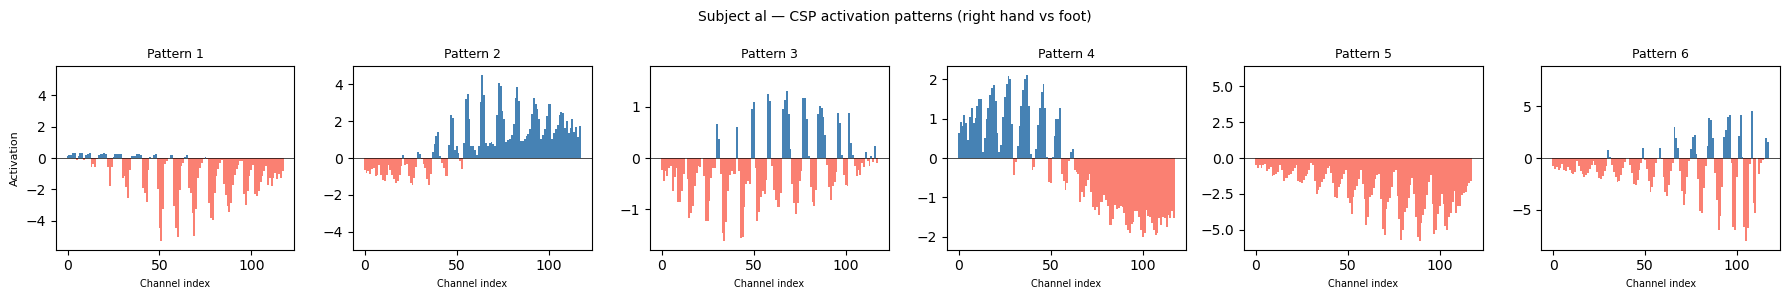

CSP features shape: (224, 6)
Feature means per component: right=[-2.809 -2.237 -1.801 -1.654 -1.318 -0.976]
                              foot =[-0.229 -0.291 -0.308 -0.369 -0.485 -1.457]


In [10]:
%matplotlib inline

PLOT_SUBJ = 'al'
d    = subjects_data[PLOT_SUBJ]
X_3d = d['X'].transpose(0, 2, 1).astype(np.float64)

csp = CSP(n_components=N_CSP, reg='ledoit_wolf', log=True)
csp.fit(X_3d, d['y'])

# patterns_ shape: (n_components, n_channels)
patterns = csp.patterns_[:N_CSP]

fig, axes = plt.subplots(1, N_CSP, figsize=(3 * N_CSP, 3))
for i, ax in enumerate(axes):
    vals = patterns[i]
    vmax = np.abs(vals).max()
    ax.bar(range(len(vals)), vals, color=['steelblue' if v > 0 else 'salmon' for v in vals],
           width=1.0, linewidth=0)
    ax.set_ylim(-vmax * 1.1, vmax * 1.1)
    ax.set_title(f'Pattern {i+1}', fontsize=9)
    ax.set_xlabel('Channel index', fontsize=7)
    ax.axhline(0, color='k', lw=0.5)
    if i == 0: ax.set_ylabel('Activation', fontsize=8)

fig.suptitle(f'Subject {PLOT_SUBJ} — CSP activation patterns (right hand vs foot)', fontsize=10)
plt.tight_layout()
plt.show()

# also show log-variance of CSP-filtered signals across time
X_csp = csp.transform(X_3d)   # (n_trials, N_CSP)
print(f'CSP features shape: {X_csp.shape}')
print(f'Feature means per component: right={X_csp[d["y"]==0].mean(0).round(3)}')
print(f'                              foot ={X_csp[d["y"]==1].mean(0).round(3)}')